In [1]:
#Building a simple toy dataset
import numpy as np
import pandas as pd

np.random.seed(42)

N = 1000

# A group (conversion 0.30)
A = np.random.binomial(1, 0.30, N)

# B group (conversion 0.35)
B = np.random.binomial(1, 0.35, N)

df = pd.DataFrame({
    "user_id": np.arange(2*N),
    "group_name": ["A"]*N + ["B"]*N,
    "purchased": np.concatenate([A, B])
})

df.head()

,user_id,group_name,purchased
0,0,A,0
1,1,A,1
2,2,A,1
3,3,A,0
4,4,A,0


In [2]:
# create data.db and put table "ab_test" in it
import sqlite3

conn = sqlite3.connect("data.db")
df.to_sql("ab_test", conn, if_exists="replace", index=False)

2000

In [3]:
query = """
SELECT 
    group_name,
    COUNT(*) as users,
    SUM(purchased) as purchases,
    AVG(purchased) as conversion_rate
FROM ab_test
GROUP BY group_name
"""

result = pd.read_sql(query, conn)
result

,group_name,users,purchases,conversion_rate
0,A,1000,288,0.288
1,B,1000,370,0.370


In [4]:
#A/B Test, p-value
from statsmodels.stats.proportion import proportions_ztest

success = result["purchases"].values
nobs = result["users"].values

z_stat, p_value = proportions_ztest(success, nobs)

print("z =", z_stat)
print("p =", p_value)

z = -3.902470650185917
p = 9.521578671879313e-05


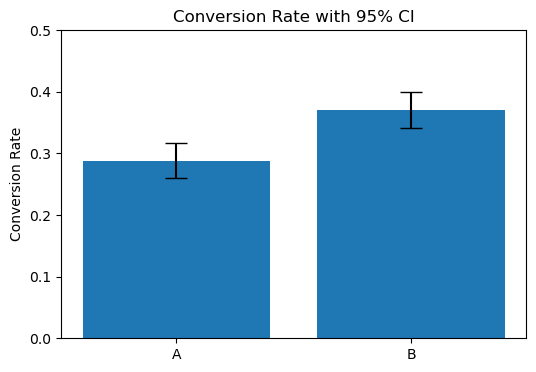

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

groups = result["group_name"]
rates = result["conversion_rate"].values
success = result["purchases"].values
nobs = result["users"].values

ci_low = []
ci_high = []

for s, n in zip(success, nobs):

    low, high = sm.stats.proportion_confint(
        s,
        n,
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

ci_low = np.array(ci_low)
ci_high = np.array(ci_high)

# error bars
yerr = [
    rates - ci_low,
    ci_high - rates
]

plt.figure(figsize=(6,4))

plt.bar(
    groups,
    rates,
    yerr=yerr,
    capsize=8
)

plt.ylabel("Conversion Rate")
plt.title("Conversion Rate with 95% CI")

plt.ylim(0, 0.5)

plt.show()

In [5]:
#Bayesian Posterior 
from scipy.stats import beta
import matplotlib.pyplot as plt

# priors
a0, b0 = 1, 1

# group A
sA, nA = success[0], nobs[0]
post_A = beta(a0 + sA, b0 + nA - sA)

# group B
sB, nB = success[1], nobs[1]
post_B = beta(a0 + sB, b0 + nB - sB)

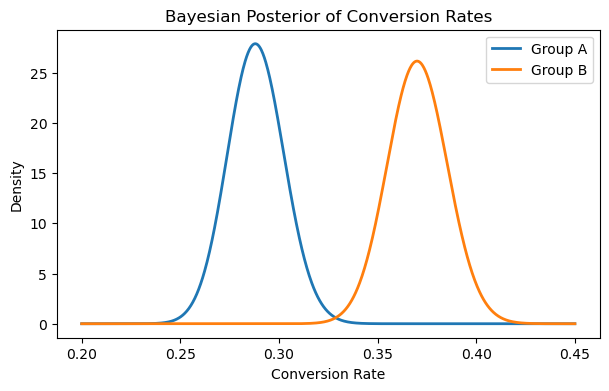

In [6]:
#Plotting posterior distributions
x = np.linspace(0.2, 0.45, 1000)

plt.figure(figsize=(7,4))
plt.plot(x, post_A.pdf(x), label="Group A", linewidth=2)
plt.plot(x, post_B.pdf(x), label="Group B", linewidth=2)

plt.title("Bayesian Posterior of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.legend()
plt.show()

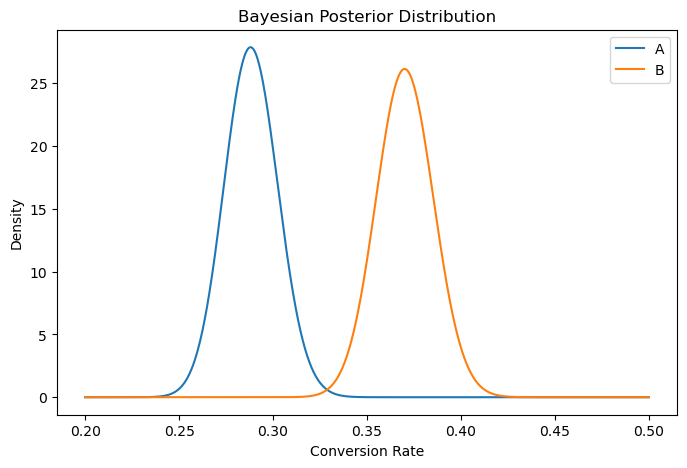

In [7]:
# more general notation
# successes
success = result["purchases"].values

# observations
nobs = result["users"].values

# beta prior
alpha_prior = 1
beta_prior = 1

x = np.linspace(0.2, 0.5, 1000)

plt.figure(figsize=(8,5))

for i, group in enumerate(result["group_name"]):

    alpha_post = alpha_prior + success[i]
    beta_post = beta_prior + nobs[i] - success[i]

    posterior = beta.pdf(x, alpha_post, beta_post)

    plt.plot(x, posterior, label=f"{group}")

plt.title("Bayesian Posterior Distribution")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")

plt.legend()

plt.show()

In [8]:
#what is the probability that B is better
samples = 100000

A_samples = post_A.rvs(samples)
B_samples = post_B.rvs(samples)

prob_B_better = np.mean(B_samples > A_samples)

print("P(B > A) =", prob_B_better)

P(B > A) = 0.99998


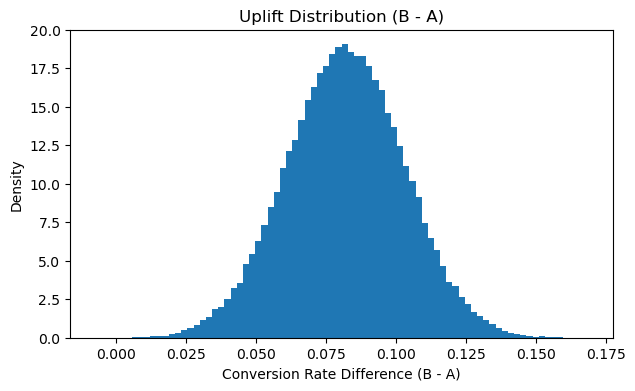

In [9]:
#Take thousands of samples for A and B from the posterior region, above.
#In each sample: B − A
#Then plot the distribution.

# posterior samples
A_samples = post_A.rvs(samples)
B_samples = post_B.rvs(samples)

# uplift
uplift = B_samples - A_samples

plt.figure(figsize=(7,4))
plt.hist(uplift, bins=80, density=True)
plt.title("Uplift Distribution (B - A)")
plt.xlabel("Conversion Rate Difference (B - A)")
plt.ylabel("Density")
plt.show()

In [10]:
print("Expected uplift:", np.mean(uplift))
print("P(B > A):", np.mean(uplift > 0))
print("P(B worse than A):", np.mean(uplift < 0))

Expected uplift: 0.08186964319236911
P(B > A): 0.99996
P(B worse than A): 4e-05


In [11]:
samples_A = beta.rvs(
    alpha_prior + success[0],
    beta_prior + nobs[0] - success[0],
    size=100000
)

samples_B = beta.rvs(
    alpha_prior + success[1],
    beta_prior + nobs[1] - success[1],
    size=100000
)

prob = np.mean(samples_B > samples_A)

print(prob)

0.99998


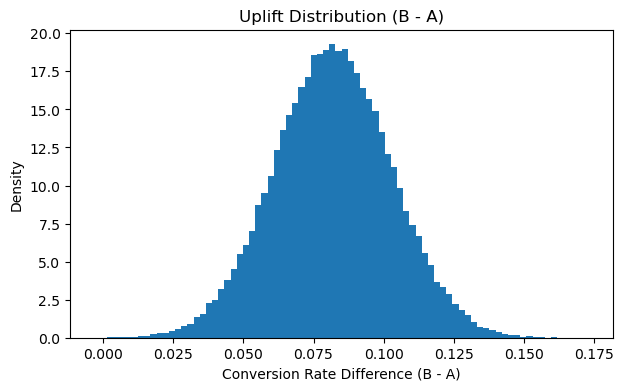

In [14]:
uplift = samples_B  - samples_A

plt.figure(figsize=(7,4))
plt.hist(uplift, bins=80, density=True)
plt.title("Uplift Distribution (B - A)")
plt.xlabel("Conversion Rate Difference (B - A)")
plt.ylabel("Density")
plt.show()

In [16]:
np.mean(uplift)

np.float64(0.08184420500288941)

In [17]:
np.percentile(uplift, [2.5, 97.5])

array([0.04065247, 0.12319316])